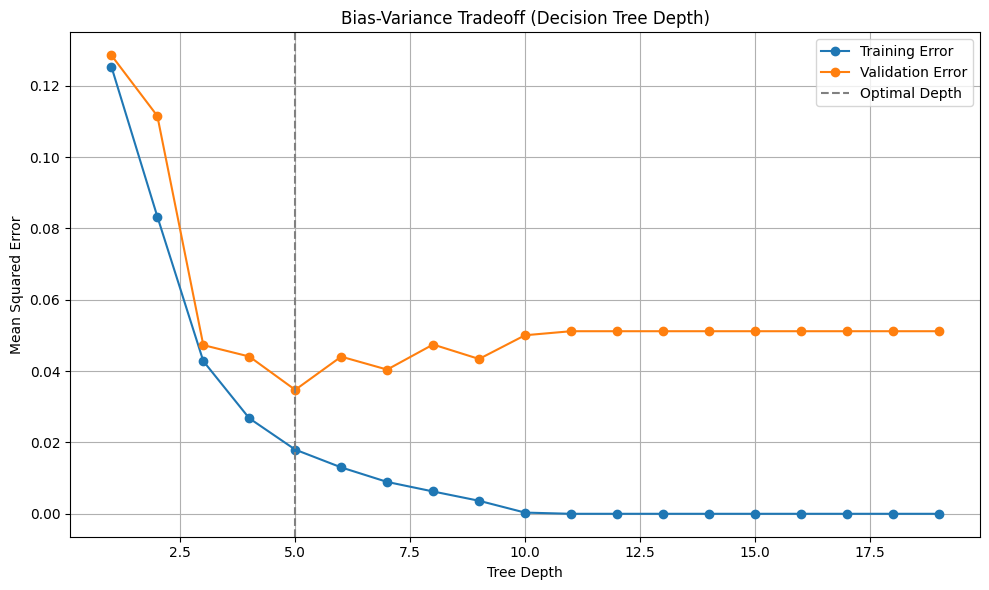

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.sort(np.random.rand(100, 1) * 5, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # sin curve + noise

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Trees of various depths
train_errors = []
val_errors = []
depths = range(1, 20)

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    val_errors.append(mean_squared_error(y_val, y_val_pred))

# Step 4: Plotting
plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors, label="Training Error", marker='o')
plt.plot(depths, val_errors, label="Validation Error", marker='o')
plt.axvline(x=np.argmin(val_errors)+1, linestyle="--", color='gray', label="Optimal Depth")
plt.title("Bias-Variance Tradeoff (Decision Tree Depth)")
plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Low Depth (e.g., 1–2): High bias, underfitting → both training and validation errors are high.

# Medium Depth (e.g., 4–6): Balanced bias and variance → validation error is lowest.

# High Depth (e.g., 10–20): Low bias, high variance → training error drops, but validation error increases.


# Shallow trees (low depth): High bias (underfitting)
# Deep trees (high depth): High variance (overfitting)

In [ ]:
Total Error = Bias² + Variance + Irreducible Error

This is how we decompose the expected prediction error at a point x:
Error due to wrong assumptions + Error due to fluctuations in training data + Irreducible error

🔹 Components:

    Bias²: How far the average model prediction is from the true function
    ➤ High bias = underfitting (e.g., linear model on nonlinear data)

    Variance: How much predictions vary across different training datasets
    ➤ High variance = overfitting (e.g., deep tree memorizing noise)

    Irreducible Error: Noise in the data we can’t explain — even with perfect models

/tmp/ipykernel_135267/245477463.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_135267/245477463.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_135267/245477463.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


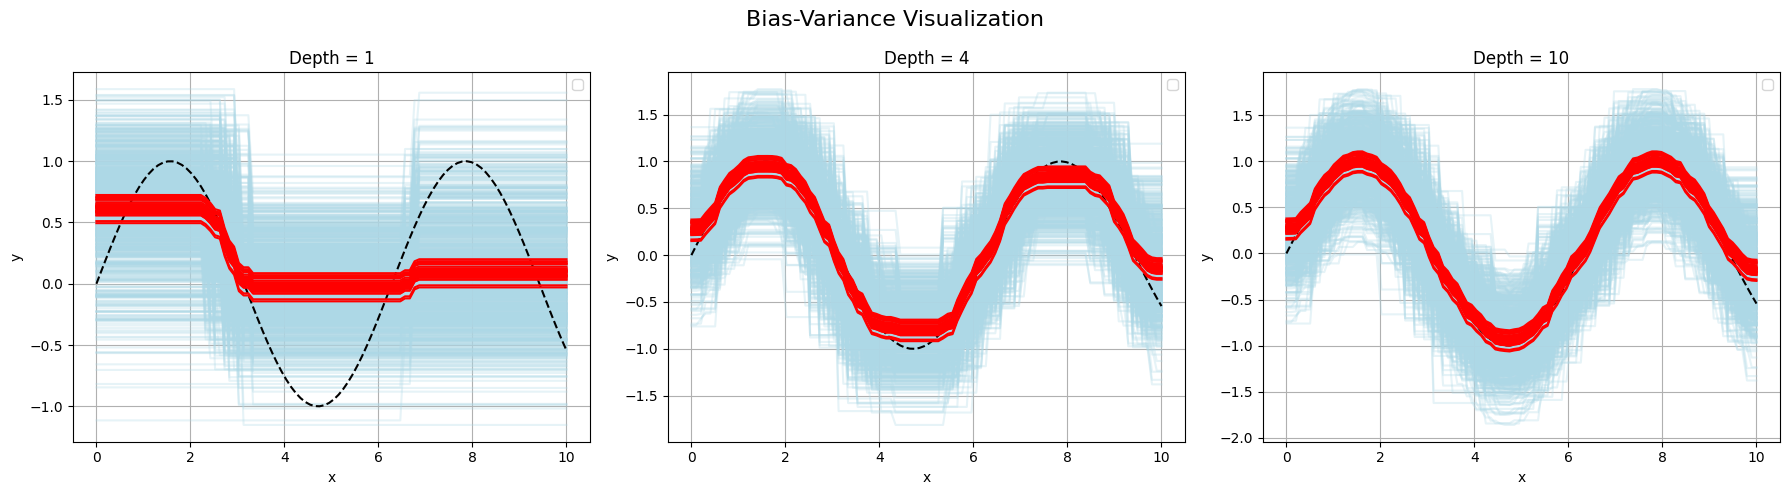

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Ground truth function (noiseless)
def true_function(x):
    return np.sin(x)

# Generate fixed test data
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_true = true_function(X_test)

# Simulate multiple training datasets
np.random.seed(42)
n_datasets = 30
X_datasets = [np.sort(np.random.rand(30, 1) * 10, axis=0) for _ in range(n_datasets)]
y_datasets = [true_function(X) + np.random.normal(0, 0.3, X.shape[0]) for X in X_datasets]

# Fit models of different depths and plot predictions
depths = [1, 4, 10]  # Low, medium, high depth (underfit → good fit → overfit)

plt.figure(figsize=(18, 5))
for i, depth in enumerate(depths):
    predictions = []
    for X_train, y_train in zip(X_datasets, y_datasets):
        model = DecisionTreeRegressor(max_depth=depth)
        model.fit(X_train, y_train)
        predictions.append(model.predict(X_test))

    predictions = np.array(predictions)
    mean_prediction = np.mean(predictions, axis=0)

    # Plot
    plt.subplot(1, 3, i+1)
    for pred in predictions:
        plt.plot(X_test, pred, color='lightblue', alpha=0.3)
    plt.plot(X_test, y_true, 'k--')
    plt.plot(X_test, mean_prediction, 'r')
    plt.title(f'Depth = {depth}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

plt.suptitle("Bias-Variance Visualization", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
Depth = 1 (Underfitting)

    Predictions are simple (almost flat lines)
    High bias, low variance

Depth = 4 (Good Fit)

    Captures the wave trend well
    Balanced bias and variance

Depth = 10 (Overfitting)

    Wildly varying predictions
    Low bias, high variance

# Ensemble Learning: A Solution to Bias-Variance Problems

# Ensemble Techniques — these combine multiple models to produce a stronger overall model.

Bagging 

It helps by reducing variance, especially for models like Decision Trees which are high-variance learners.


Bootstrap Aggregating: Train multiple models on different subsets (with replacement) of the data.

Random Forest: Adds extra randomness — each tree uses a random subset of features.

Goal: Reduce variance (i.e., more stable, less overfitting than a single decision tree).


# Random forest

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Create a synthetic classification dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, 
                           n_redundant=2, n_classes=2, random_state=42)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [6]:
# decision tree vs random forest

# Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Accuracy comparison
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Decision Tree Accuracy: 0.8866666666666667
Random Forest Accuracy: 0.94



--- Decision Tree Report ---

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       158
           1       0.88      0.88      0.88       142

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300


--- Random Forest Report ---

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       158
           1       0.94      0.93      0.94       142

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



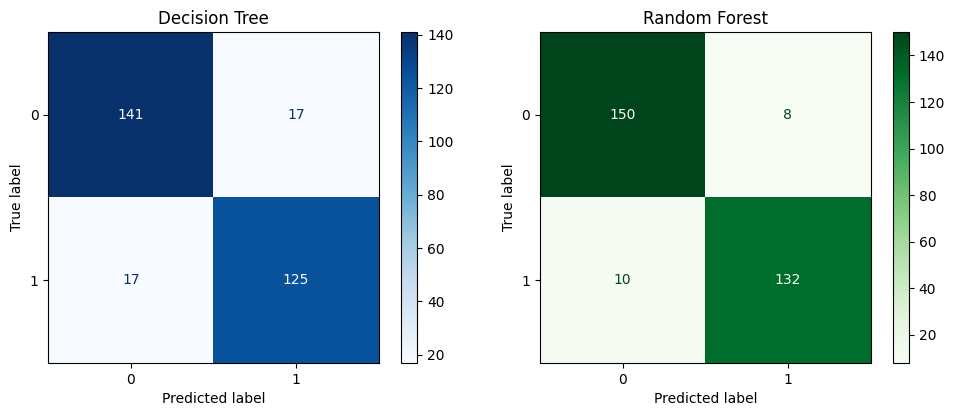

In [7]:
print("\n--- Decision Tree Report ---\n")
print(classification_report(y_test, dt_pred))

print("\n--- Random Forest Report ---\n")
print(classification_report(y_test, rf_pred))

# Confusion matrix
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, ax=axs[0], cmap="Blues")
axs[0].set_title("Decision Tree")

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axs[1], cmap="Greens")
axs[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


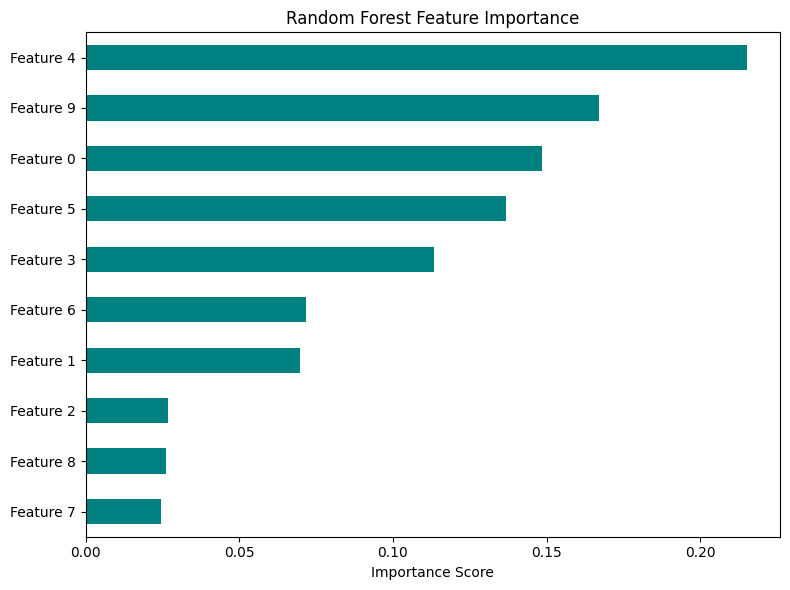

In [8]:
import pandas as pd
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=feature_names).sort_values()

# Plot
plt.figure(figsize=(8, 6))
forest_importances.plot(kind='barh', color='teal')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


Each decision tree in the forest splits on features that maximize impurity reduction (like Gini impurity or entropy in classification, MSE in regression).

For every feature used in splits:
    Measure the reduction in impurity due to that feature’s split.
    The more a feature helps to reduce impurity, the more important it is.

Across all trees, these reductions are:

    Summed up for each feature.
    Averaged (optionally normalized) across the forest.

The result is an importance score:
feature_importances_[i] = total decrease in impurity from feature i / total decrease from all features

In [ ]:
# pseudo code of how it actually gets the feature importance.
# Pseudo-internal calculation
# for tree in forest:
#     for node in tree:
#         if node splits on feature_i:
#             importance_i += impurity_reduction_weighted_by_node_samples


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Example of  Titanic dataset
import seaborn as sns
df = sns.load_dataset("titanic").dropna(subset=['age', 'embarked', 'fare', 'sex', 'pclass', 'survived'])

# Preprocess
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X = df[['pclass', 'sex', 'age', 'fare', 'embarked']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.80      0.85      0.82        99
           1       0.79      0.73      0.76        79

    accuracy                           0.80       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



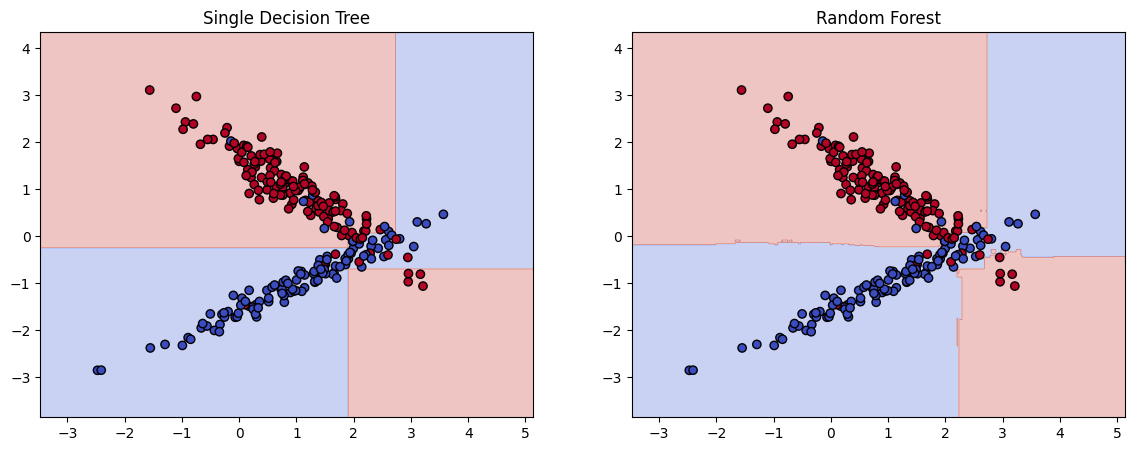

In [22]:
# Decision Tree: High variance, sharp boundaries, more prone to overfitting.
# Random Forest: Smoother, more generalized boundaries.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a synthetic dataset
X, y = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, flip_y=0.1, class_sep=1.0, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Decision Tree
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Random Forest
forest = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42)
forest.fit(X_train, y_train)

# Meshgrid for decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_tree = tree.predict(grid).reshape(xx.shape)
Z_forest = forest.predict(grid).reshape(xx.shape)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].contourf(xx, yy, Z_tree, alpha=0.3, cmap=plt.cm.coolwarm)
axs[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
axs[0].set_title("Single Decision Tree")

axs[1].contourf(xx, yy, Z_forest, alpha=0.3, cmap=plt.cm.coolwarm)
axs[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
axs[1].set_title("Random Forest")

plt.show()


# Bootstrap Aggregating

Bagging is an ensemble technique that:

    Trains multiple models (typically the same type, like Decision Trees),
    Each on a random subset of the data (with replacement),
    Then averages or votes their predictions.
    "Bagging" = Bootstrapped sampling + Aggregation

1. Bootstrap Sampling

Each model gets a different subset of the original data, drawn with replacement:

    If you have N samples, you draw N samples with replacement → some rows repeat, some are left out.
    This introduces diversity across models.

2. Aggregation

    Classification: Majority vote
    Regression: Average prediction

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

#Single Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)

# Bagging of Decision Trees
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    bootstrap=True,
    random_state=42
)
bagging.fit(X_train, y_train)
bagging_preds = bagging.predict(X_test)

# 📊 Compare accuracy
print("Single Decision Tree Accuracy:", accuracy_score(y_test, tree_preds))
print("Bagging Accuracy:", accuracy_score(y_test, bagging_preds))

# Optional: Classification Reports
print("\nSingle Decision Tree Report:\n", classification_report(y_test, tree_preds))
print("\nBagging Classifier Report:\n", classification_report(y_test, bagging_preds))


Single Decision Tree Accuracy: 0.951048951048951
Bagging Accuracy: 0.958041958041958

Single Decision Tree Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94        54
           1       0.97      0.96      0.96        89

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143


Bagging Classifier Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [14]:
# A single decision tree has low bias but high variance.
# Bagging reduces the variance by averaging multiple uncorrelated trees, hence improves generalization.

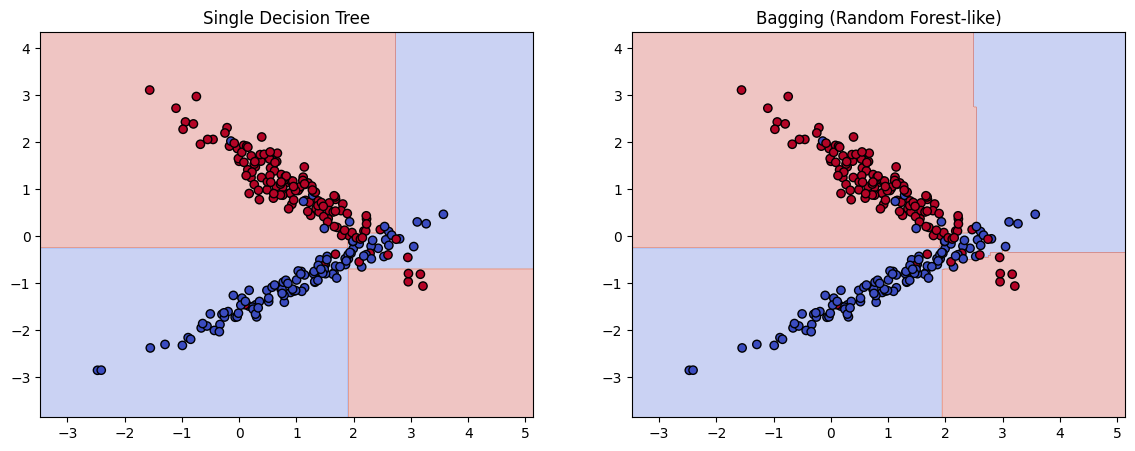

In [16]:
# An example  to show how bagging smoothens the decision boundary compared to a single tree, 
# showing reduced variance and improved generalization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create synthetic 2D dataset
X, y = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, flip_y=0.1, class_sep=1.0, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train single decision tree
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Train bagging classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train, y_train)

# Meshgrid for visualization
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_tree = tree.predict(grid).reshape(xx.shape)
Z_bagging = bagging.predict(grid).reshape(xx.shape)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].contourf(xx, yy, Z_tree, alpha=0.3, cmap=plt.cm.coolwarm)
axs[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
axs[0].set_title("Single Decision Tree")

axs[1].contourf(xx, yy, Z_bagging, alpha=0.3, cmap=plt.cm.coolwarm)
axs[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
axs[1].set_title("Bagging (Random Forest-like)")

plt.show()


# a comparsion to show the reduction in variance

In [26]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Create synthetic dataset
X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=42
)

# Define models
tree = DecisionTreeClassifier(random_state=42)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    bootstrap=True,
    random_state=42
)
forest = RandomForestClassifier(n_estimators=50, random_state=42)

# Perform 10-fold cross-validation
tree_scores = cross_val_score(tree, X, y, cv=10)
bagging_scores = cross_val_score(bagging, X, y, cv=10)
forest_scores = cross_val_score(forest, X, y, cv=10)

# Show results
print("Model           Mean Accuracy   Variance")
print(f"Decision Tree   {tree_scores.mean():.4f}         {tree_scores.var():.6f}")
print(f"Bagging         {bagging_scores.mean():.4f}         {bagging_scores.var():.6f}")
print(f"Random Forest   {forest_scores.mean():.4f}         {forest_scores.var():.6f}")


Model           Mean Accuracy   Variance
Decision Tree   0.7960         0.001864
Bagging         0.8970         0.000481
Random Forest   0.9150         0.000605


In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Define models
tree = DecisionTreeClassifier(random_state=42)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    bootstrap=True,
    random_state=42
)
forest = RandomForestClassifier(n_estimators=50, random_state=42)

# Cross-validation
tree_scores = cross_val_score(tree, X, y, cv=10)
bagging_scores = cross_val_score(bagging, X, y, cv=10)
forest_scores = cross_val_score(forest, X, y, cv=10)

# Display
print("Model           Mean Accuracy   Variance")
print(f"Decision Tree   {tree_scores.mean():.4f}         {tree_scores.var():.6f}")
print(f"Bagging         {bagging_scores.mean():.4f}         {bagging_scores.var():.6f}")
print(f"Random Forest   {forest_scores.mean():.4f}         {forest_scores.var():.6f}")


Model           Mean Accuracy   Variance
Decision Tree   0.9280         0.001071
Bagging         0.9544         0.001059
Random Forest   0.9613         0.000788


In [ ]:
Notice anything ??

# random feature selection in Random Forests vs. pure resampling in Bagging.